In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv('kidney_disease.csv')
df

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,395,55.0,80.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,...,47,6700,4.9,no,no,no,good,no,no,notckd
396,396,42.0,70.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,...,54,7800,6.2,no,no,no,good,no,no,notckd
397,397,12.0,80.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,...,49,6600,5.4,no,no,no,good,no,no,notckd
398,398,17.0,60.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,...,51,7200,5.9,no,no,no,good,no,no,notckd


In [3]:
df.shape

(400, 26)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              400 non-null    int64  
 1   age             391 non-null    float64
 2   bp              388 non-null    float64
 3   sg              353 non-null    float64
 4   al              354 non-null    float64
 5   su              351 non-null    float64
 6   rbc             248 non-null    object 
 7   pc              335 non-null    object 
 8   pcc             396 non-null    object 
 9   ba              396 non-null    object 
 10  bgr             356 non-null    float64
 11  bu              381 non-null    float64
 12  sc              383 non-null    float64
 13  sod             313 non-null    float64
 14  pot             312 non-null    float64
 15  hemo            348 non-null    float64
 16  pcv             330 non-null    object 
 17  wc              295 non-null    obj

In [5]:
df.drop("id",axis=1,inplace=True)

In [6]:
df.head()

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,...,35,7300,4.6,no,no,no,good,no,no,ckd


In [7]:
df.columns

Index(['age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr', 'bu',
       'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc', 'htn', 'dm', 'cad',
       'appet', 'pe', 'ane', 'classification'],
      dtype='object')

In [8]:
df.columns = ['age', 'blood_pressure', 'specific_gravity', 'albumin', 'sugar', 'red_blood_cells', 'pus_cell',
              'pus_cell_clumps', 'bacteria', 'blood_glucose_random', 'blood_urea', 'serum_creatinine', 'sodium',
              'potassium', 'haemoglobin', 'packed_cell_volume', 'white_blood_cell_count', 'red_blood_cell_count',
              'hypertension', 'diabetes_mellitus', 'coronary_artery_disease', 'appetite', 'peda_edema',
              'aanemia', 'class']

In [9]:
df.describe()

,age,blood_pressure,specific_gravity,albumin,sugar,blood_glucose_random,blood_urea,serum_creatinine,sodium,potassium,haemoglobin
count,391.000000,388.000000,353.000000,354.000000,351.000000,356.000000,381.000000,383.000000,313.000000,312.000000,348.000000
mean,51.483376,76.469072,1.017408,1.016949,0.450142,148.036517,57.425722,3.072454,137.528754,4.627244,12.526437
std,17.169714,13.683637,0.005717,1.352679,1.099191,79.281714,50.503006,5.741126,10.408752,3.193904,2.912587
min,2.000000,50.000000,1.005000,0.000000,0.000000,22.000000,1.500000,0.400000,4.500000,2.500000,3.100000
25%,42.000000,70.000000,1.010000,0.000000,0.000000,99.000000,27.000000,0.900000,135.000000,3.800000,10.300000
50%,55.000000,80.000000,1.020000,0.000000,0.000000,121.000000,42.000000,1.300000,138.000000,4.400000,12.650000
75%,64.500000,80.000000,1.020000,2.000000,0.000000,163.000000,66.000000,2.800000,142.000000,4.900000,15.000000
max,90.000000,180.000000,1.025000,5.000000,5.000000,490.000000,391.000000,76.000000,163.000000,47.000000,17.800000


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      391 non-null    float64
 1   blood_pressure           388 non-null    float64
 2   specific_gravity         353 non-null    float64
 3   albumin                  354 non-null    float64
 4   sugar                    351 non-null    float64
 5   red_blood_cells          248 non-null    object 
 6   pus_cell                 335 non-null    object 
 7   pus_cell_clumps          396 non-null    object 
 8   bacteria                 396 non-null    object 
 9   blood_glucose_random     356 non-null    float64
 10  blood_urea               381 non-null    float64
 11  serum_creatinine         383 non-null    float64
 12  sodium                   313 non-null    float64
 13  potassium                312 non-null    float64
 14  haemoglobin              3

In [11]:
""" packed_cell_volume white_blood_cell_count red_blood_cell_count ---convet this data types into numeric"""

' packed_cell_volume white_blood_cell_count red_blood_cell_count ---convet this data types into numeric'

In [12]:
df["packed_cell_volume"]=pd.to_numeric(df["packed_cell_volume"],errors='coerce')

In [13]:
df["white_blood_cell_count"]=pd.to_numeric(df["white_blood_cell_count"],errors='coerce')
df['red_blood_cell_count']=pd.to_numeric(df['red_blood_cell_count'],errors='coerce')

In [14]:
df.dtypes

age                        float64
blood_pressure             float64
specific_gravity           float64
albumin                    float64
sugar                      float64
red_blood_cells             object
pus_cell                    object
pus_cell_clumps             object
bacteria                    object
blood_glucose_random       float64
blood_urea                 float64
serum_creatinine           float64
sodium                     float64
potassium                  float64
haemoglobin                float64
packed_cell_volume         float64
white_blood_cell_count     float64
red_blood_cell_count       float64
hypertension                object
diabetes_mellitus           object
coronary_artery_disease     object
appetite                    object
peda_edema                  object
aanemia                     object
class                       object
dtype: object

In [15]:
num_columns=df.select_dtypes(include="number").columns
num_columns

Index(['age', 'blood_pressure', 'specific_gravity', 'albumin', 'sugar',
       'blood_glucose_random', 'blood_urea', 'serum_creatinine', 'sodium',
       'potassium', 'haemoglobin', 'packed_cell_volume',
       'white_blood_cell_count', 'red_blood_cell_count'],
      dtype='object')

In [16]:
cateo_columns=df.select_dtypes(include='object').columns
cateo_columns

Index(['red_blood_cells', 'pus_cell', 'pus_cell_clumps', 'bacteria',
       'hypertension', 'diabetes_mellitus', 'coronary_artery_disease',
       'appetite', 'peda_edema', 'aanemia', 'class'],
      dtype='object')

In [17]:
df['age'].isnull().sum()

np.int64(9)

In [18]:
df.dropna(subset=['age'], inplace=True)


In [19]:
df['age'].isnull().sum()

np.int64(0)

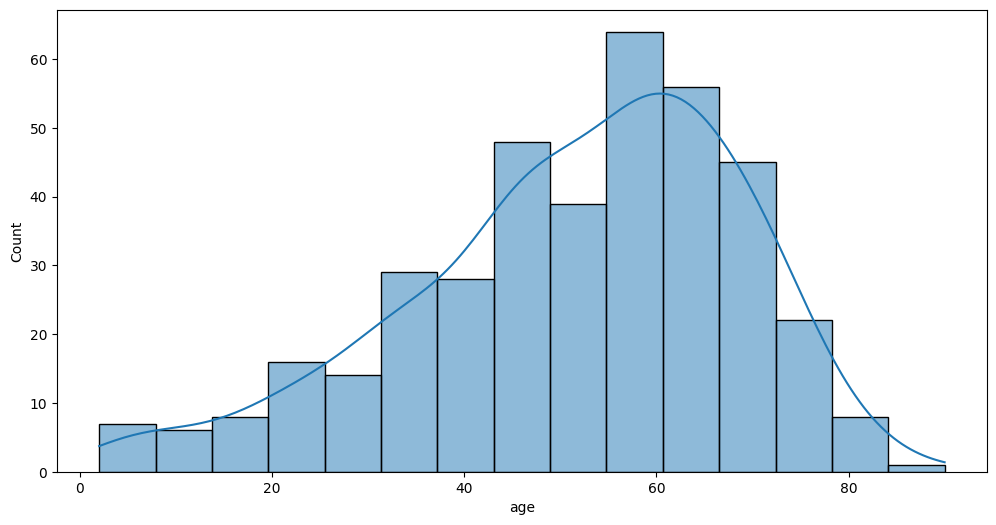

In [20]:
#univariate analysis
plt.figure(figsize=(12,6))
sns.histplot(x=df['age'],data=df,kde=True,palette='Set2')
plt.show()


In [21]:
df.columns

Index(['age', 'blood_pressure', 'specific_gravity', 'albumin', 'sugar',
       'red_blood_cells', 'pus_cell', 'pus_cell_clumps', 'bacteria',
       'blood_glucose_random', 'blood_urea', 'serum_creatinine', 'sodium',
       'potassium', 'haemoglobin', 'packed_cell_volume',
       'white_blood_cell_count', 'red_blood_cell_count', 'hypertension',
       'diabetes_mellitus', 'coronary_artery_disease', 'appetite',
       'peda_edema', 'aanemia', 'class'],
      dtype='object')

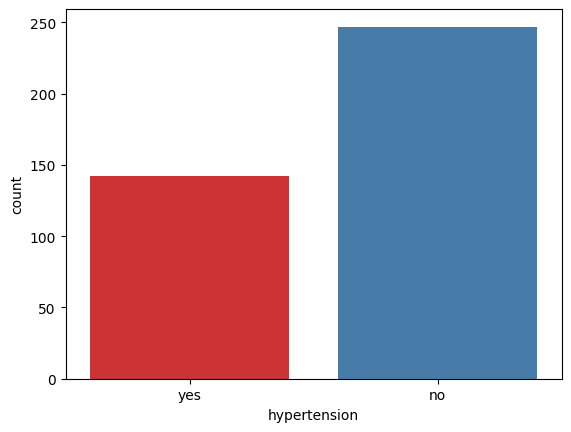

In [22]:
sns.countplot(x = 'hypertension', data = df, palette = 'Set1')
plt.show()

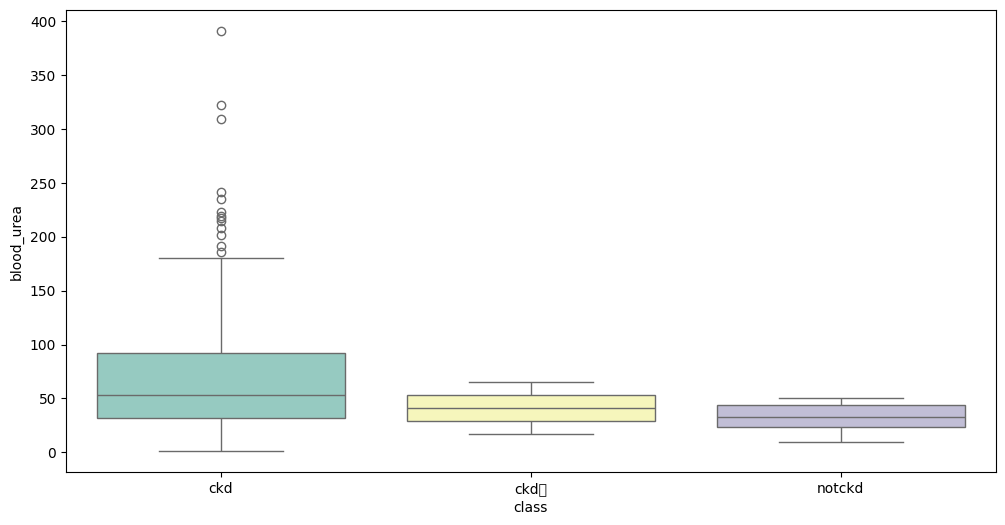

In [23]:
plt.figure(figsize=(12,6))
sns.boxplot(x = 'class', y = 'blood_urea', data = df, palette = 'Set3')
plt.show()

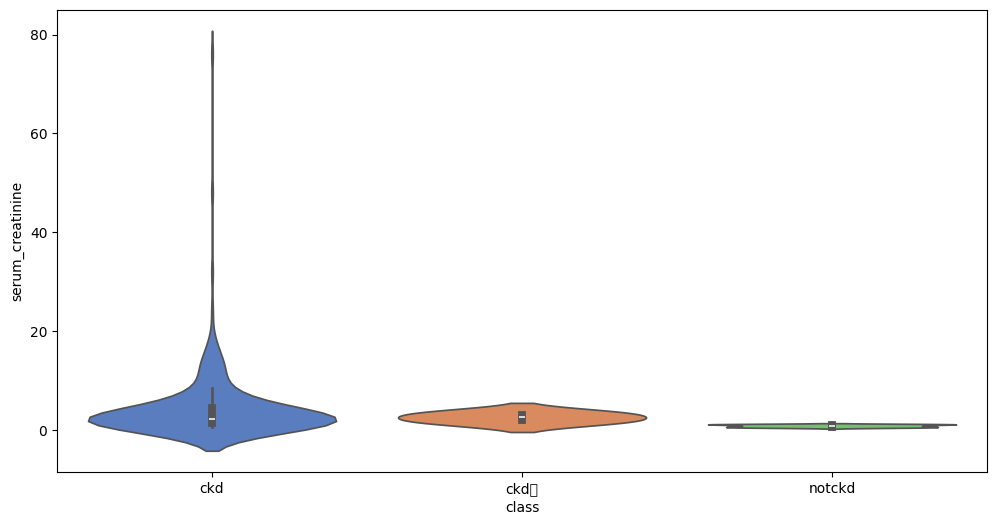

In [24]:
plt.figure(figsize=(12,6))
sns.violinplot(x = 'class', y = 'serum_creatinine', data = df, palette = "muted")
plt.show()

<Axes: xlabel='aanemia', ylabel='count'>

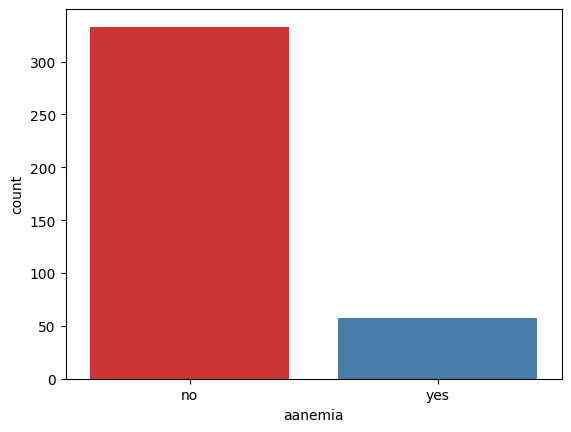

In [25]:
sns.countplot(x = 'aanemia', data = df, palette = 'Set1')

In [26]:
df.columns

Index(['age', 'blood_pressure', 'specific_gravity', 'albumin', 'sugar',
       'red_blood_cells', 'pus_cell', 'pus_cell_clumps', 'bacteria',
       'blood_glucose_random', 'blood_urea', 'serum_creatinine', 'sodium',
       'potassium', 'haemoglobin', 'packed_cell_volume',
       'white_blood_cell_count', 'red_blood_cell_count', 'hypertension',
       'diabetes_mellitus', 'coronary_artery_disease', 'appetite',
       'peda_edema', 'aanemia', 'class'],
      dtype='object')

In [27]:
df['appetite'].value_counts()

appetite
good    309
poor     81
Name: count, dtype: int64

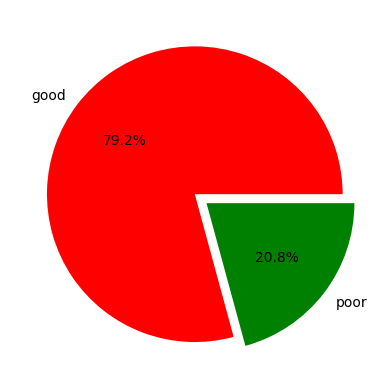

In [28]:
plt.pie(df['appetite'].value_counts(),labels=df['appetite'].value_counts().index,autopct='%1.1f%%',colors=['Red','green'],
       explode = (0, 0.1) )
plt.show()

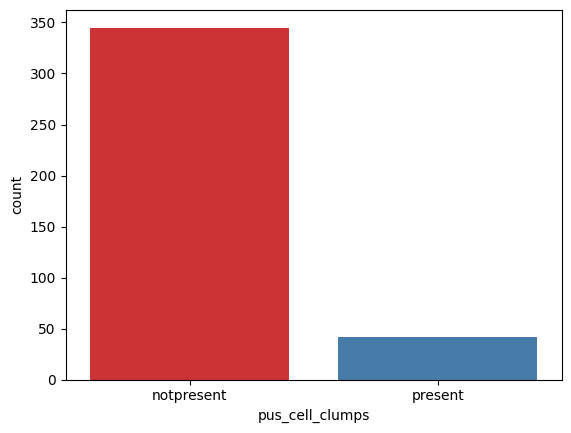

In [29]:
sns.countplot(x = 'pus_cell_clumps', data = df,palette="Set1")
plt.show()

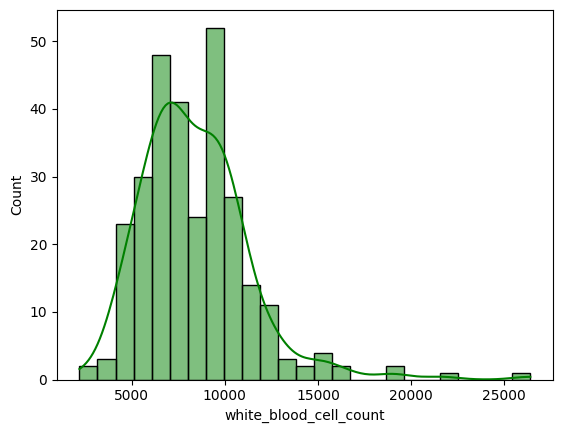

In [30]:
sns.histplot(df['white_blood_cell_count'].dropna(),kde = True, color = 'Green')
plt.show()

In [31]:
df['diabetes_mellitus'].value_counts()

diabetes_mellitus
no       253
yes      131
\tno       3
\tyes      2
Name: count, dtype: int64

In [32]:
df['diabetes_mellitus'] = df['diabetes_mellitus'].str.strip()
c=df['diabetes_mellitus'].value_counts()
c

diabetes_mellitus
no     256
yes    133
Name: count, dtype: int64

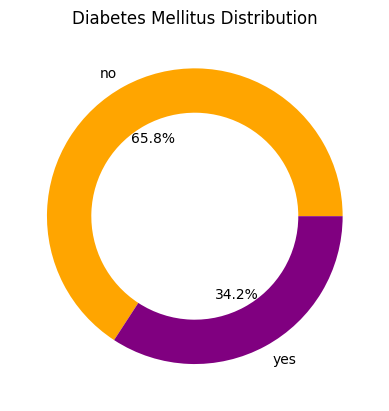

In [33]:
plt.pie(c,labels=c.index,autopct='%1.1f%%',colors=['orange','purple'],wedgeprops=dict(width=0.3))  # donut effect)
plt.title("Diabetes Mellitus Distribution")
plt.show()

In [34]:
df['coronary_artery_disease'].unique()

array(['no', 'yes', '\tno', nan], dtype=object)

In [35]:
df['coronary_artery_disease'] = df['coronary_artery_disease'].str.strip()


In [36]:
df['coronary_artery_disease'].value_counts()

coronary_artery_disease
no     355
yes     34
Name: count, dtype: int64

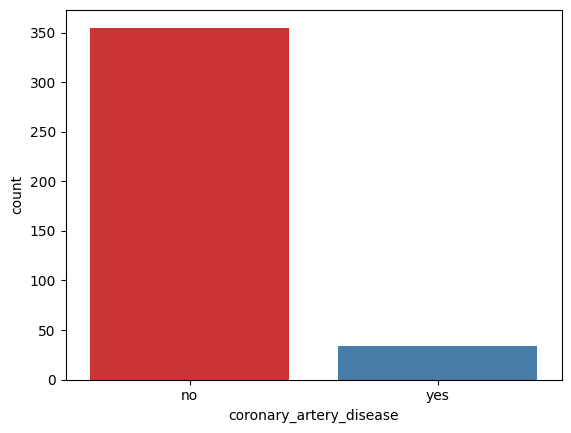

In [37]:
sns.countplot(x = 'coronary_artery_disease',palette="Set1", data = df)
plt.show()

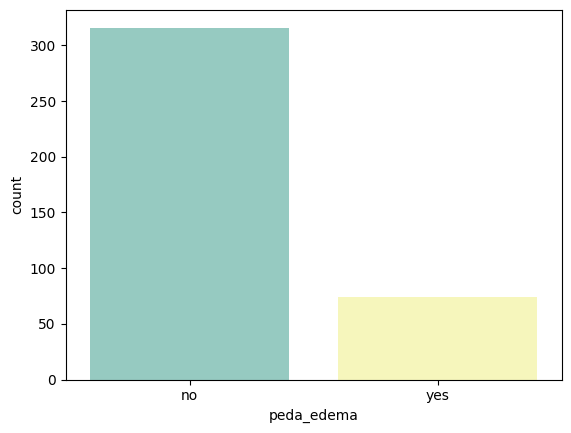

In [38]:
sns.countplot(x = 'peda_edema', data = df,palette='Set3')
plt.show()

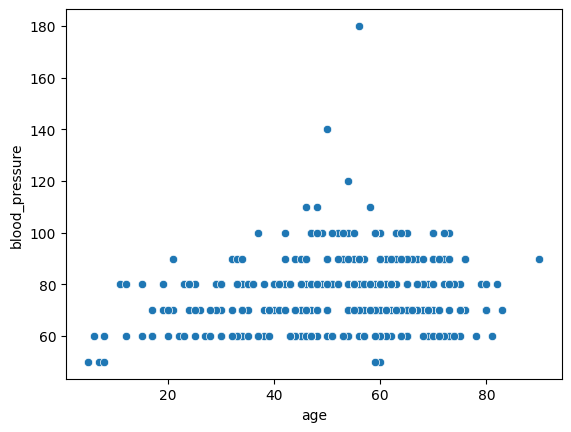

In [39]:
#bivariate analysis

sns.scatterplot(x = 'age', y = 'blood_pressure', data = df,palette='Set1')
plt.show()

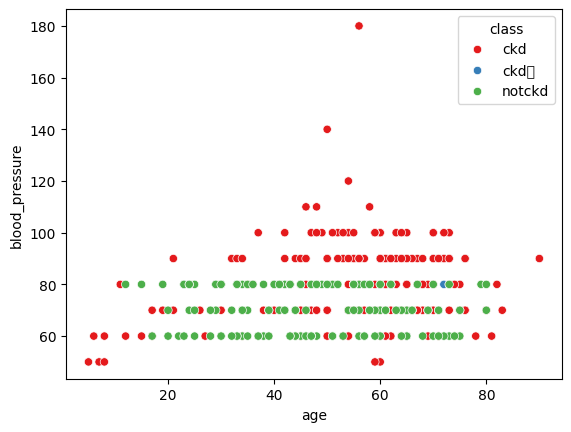

In [40]:
sns.scatterplot(x = 'age', y = 'blood_pressure', data = df, hue = 'class', palette = 'Set1')
plt.show()

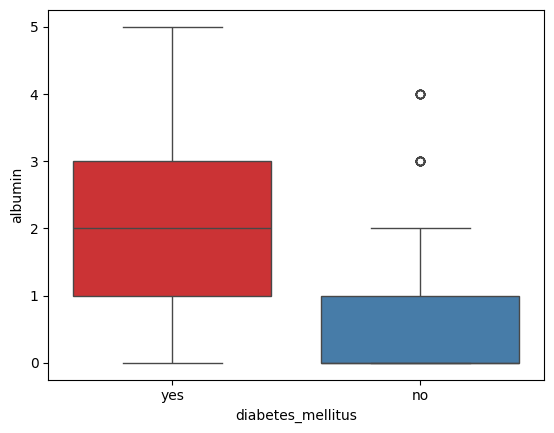

In [41]:
sns.boxplot(x = 'diabetes_mellitus', y = 'albumin', palette='Set1',data =df)
plt.show()

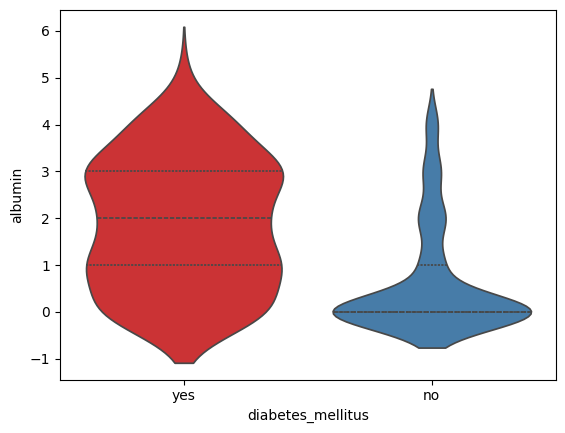

In [42]:
sns.violinplot(x = 'diabetes_mellitus', y = 'albumin', data =df, inner= 'quartile',palette="Set1")
plt.show()

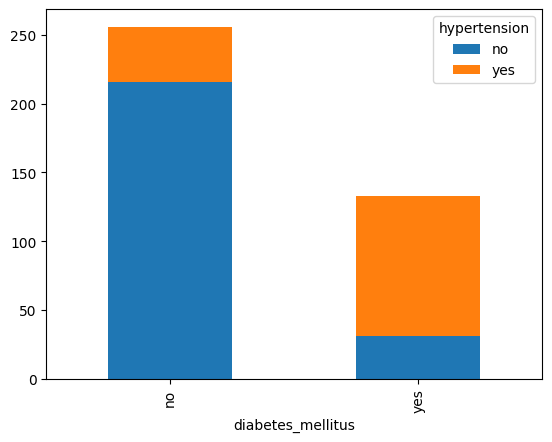

In [43]:
#stacked bar chart
diabetes_hypertension = pd.crosstab(df['diabetes_mellitus'], df['hypertension'])

diabetes_hypertension.plot(kind = 'bar', stacked = True)
plt.show()

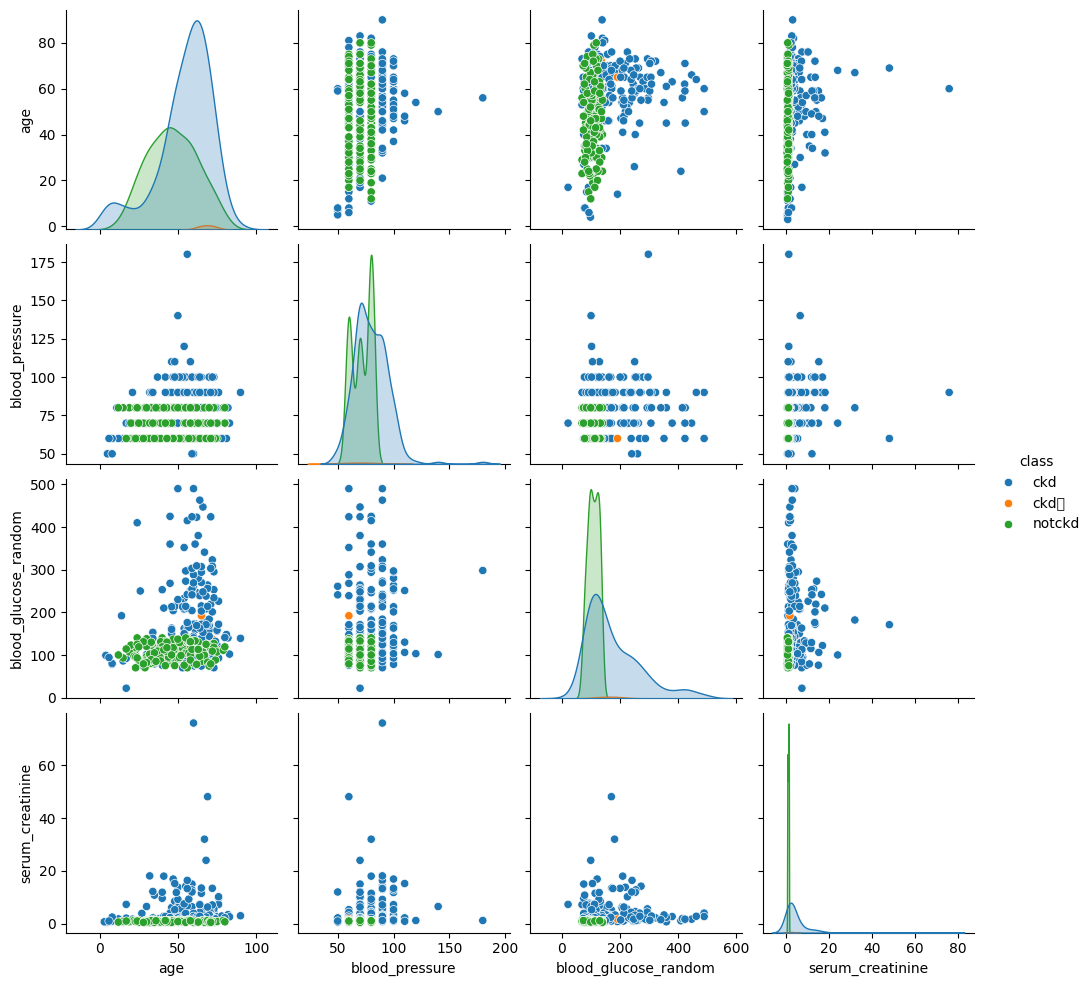

In [47]:
####           pairplot
cols = ['age', 'blood_pressure', 'blood_glucose_random', 'serum_creatinine', 'class']
sns.pairplot(data=df[cols],hue="class")
plt.show()

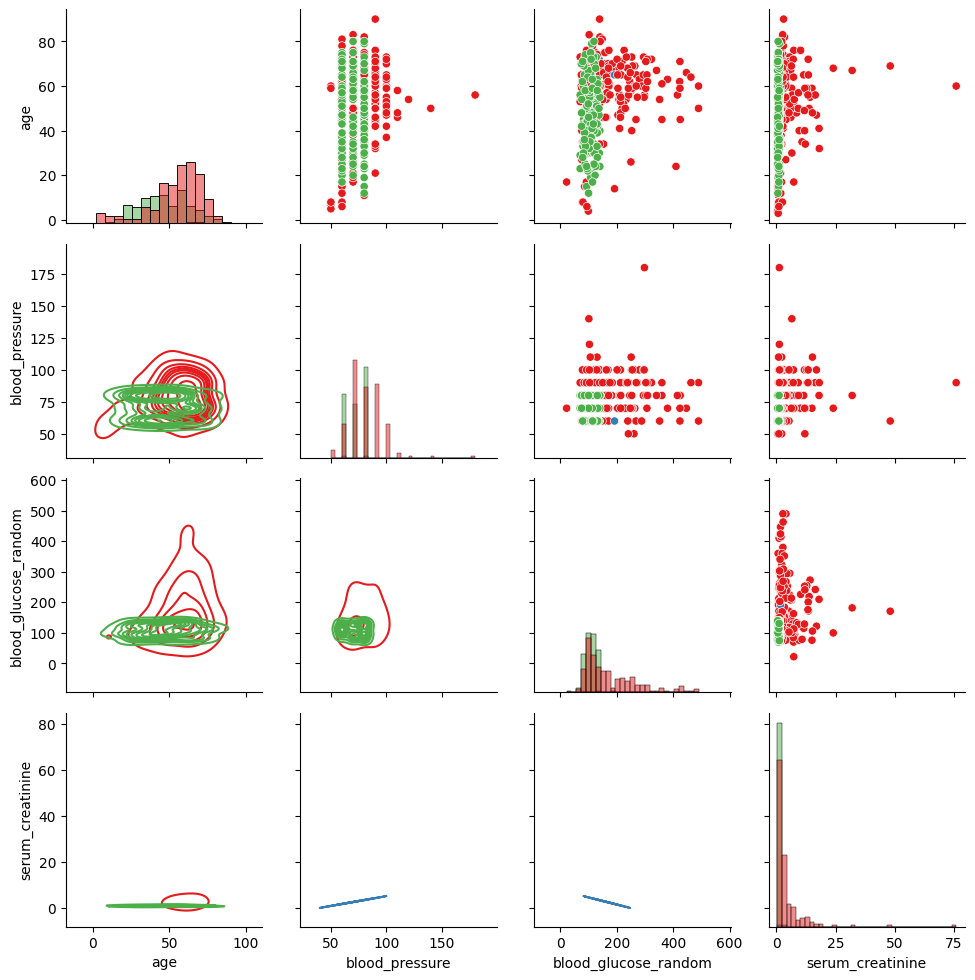

In [55]:
cols = ['age', 'blood_pressure', 'blood_glucose_random', 'serum_creatinine', 'class']
g=sns.PairGrid(df[cols],hue="class",palette="Set1")
g.map_upper(sns.scatterplot)
g.map_lower(sns.kdeplot)
g.map_diag(sns.histplot)
plt.show()

<Axes: >

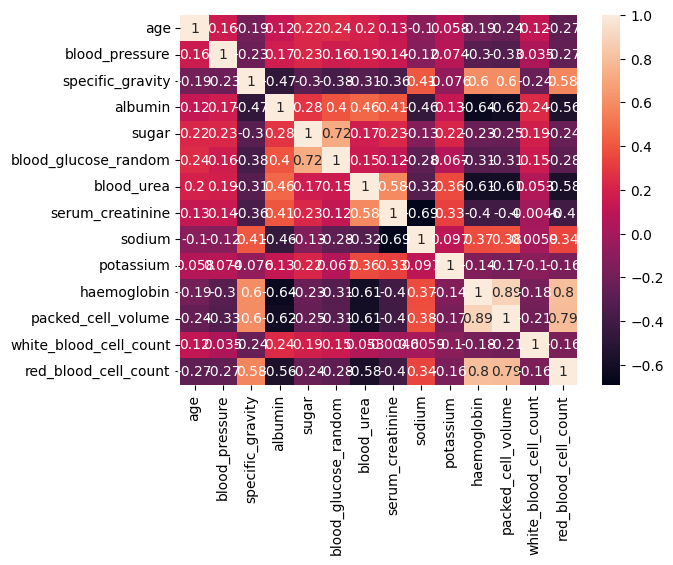

In [58]:
#heatmap
corr=df.corr(numeric_only=True)
sns.heatmap(corr,annot=True)

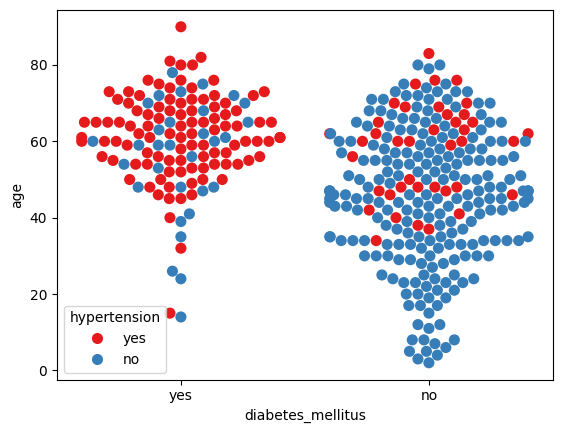

In [60]:
sns.swarmplot(x='diabetes_mellitus', y='age', hue='hypertension', data=df, palette='Set1', size=8)
plt.show()

In [61]:
#3d plot

In [62]:
import plotly.express as px

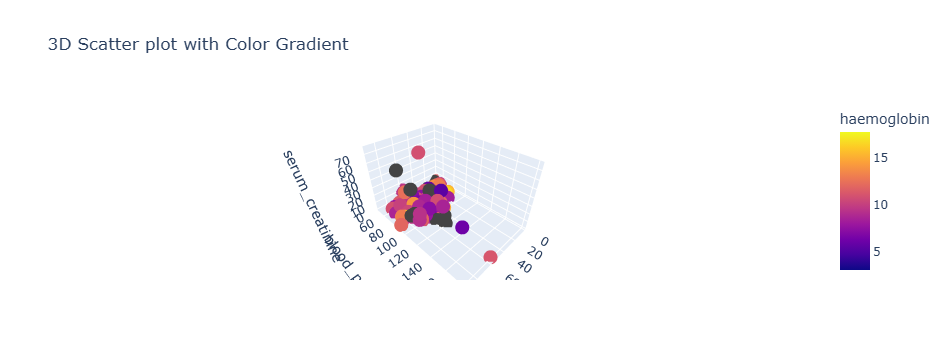

In [78]:
fig = px.scatter_3d(df, x='age', y='blood_pressure', z='serum_creatinine', color='haemoglobin',
                    title='3D Scatter plot with Color Gradient')
fig.show()


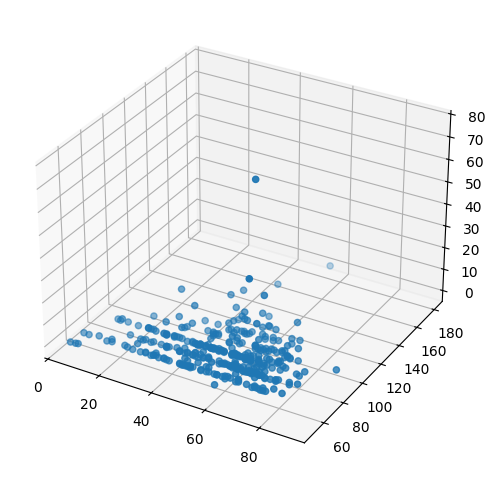

In [76]:
##
fig=plt.figure(figsize=(12,6))
ax=fig.add_subplot(111,projection="3d")
ax.scatter(df['age'], df['blood_pressure'], df['serum_creatinine'])
plt.show()